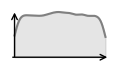

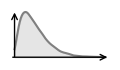

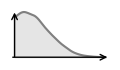

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from pathlib import Path

# Ensure the output directory exists
output_dir = Path("Figure/LvmodelCartoon")
output_dir.mkdir(parents=True, exist_ok=True)

# Helper function to plot with arrows for axes and transparent shaded area
def plot_with_arrows(x, y, filename, figsize=(1, 0.5), color='gray'):
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(x, y, color=color)
    ax.fill_between(x, y, color=color, alpha=0.2)
    
    # Remove default spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove ticks
    ax.set_xticks([])
    ax.set_yticks([])

    # Add arrows for axes
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    ax.annotate('', xy=(xmax, 0), xycoords='data', xytext=(xmin, 0),
                arrowprops=dict(arrowstyle="->", color='black'))
    ax.annotate('', xy=(0, ymax), xycoords='data', xytext=(0, ymin),
                arrowprops=dict(arrowstyle="->", color='black'))

    plt.tight_layout(pad=0)
    plt.savefig(output_dir / filename, format='svg')
    plt.show()

# Uniform distribution
data_uniform = np.random.uniform(0, 1, 10000)
kde_uniform = gaussian_kde(data_uniform)
x_uniform = np.linspace(0, 1, 1000)
plot_with_arrows(x_uniform, kde_uniform(x_uniform), "uniform.svg")

# Gamma distribution
data_gamma = np.random.gamma(shape=2, scale=1, size=10000)
kde_gamma = gaussian_kde(data_gamma)
x_gamma = np.linspace(0, np.percentile(data_gamma, 99.9), 1000)
plot_with_arrows(x_gamma, kde_gamma(x_gamma), "gamma.svg")

# Gaussian distribution
data_gaussian = np.random.normal(0.5, 1, 10000)
kde_gaussian = gaussian_kde(data_gaussian)
x_gaussian = np.linspace(0, 4, 1000)
plot_with_arrows(x_gaussian, kde_gaussian(x_gaussian), "gaussian.svg")
